In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

In [25]:
powerplant_df = pd.read_csv(
    "datasets/powerplant_data.csv"
)

In [26]:
# Inspecting
powerplant_df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [27]:
powerplant_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [28]:
# duplicates
powerplant_df.duplicated().sum()
# Duplicates are there but there is high chance they could be natural

np.int64(41)

In [29]:
# no inconsistency (no string features)

In [30]:
# missing values
powerplant_df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [31]:
# split input output
X = powerplant_df.drop(columns=[
    "PE"
])
y = powerplant_df[["PE"]]

In [32]:
# split train & test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
# Feature Engineering
# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Deep Learning

In [34]:
# conversion to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)


In [35]:
print(X_test_tensor.shape)
print(y_test_tensor.shape)

torch.Size([1914, 4])
torch.Size([1914, 1])


In [36]:
# dataset and dataloader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=30, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=30, shuffle=True)

In [37]:
# ANN Model Creation
class PowerPlantANN(nn.Module):
    def __init__(self):
        super().__init__()

        # Architecutre of mode:
        # Input layer take four features.
        # Two hidden layers each consisting of 6 neurons
        # Ouput layer has one neuron

        self.model = nn.Sequential(
            # First hidden layer
            nn.Linear(X_train.shape[1], 4),
            nn.ReLU(),
    
            # Second hidden layer
            nn.Linear(4, 4),
            nn.ReLU(),
    
            # Output layer
            nn.Linear(4, 1)
        )

    def forward(self, x):
        return self.model(x)
    


In [38]:
ann_model = PowerPlantANN()

criterion = nn.MSELoss()

optimizer = optim.Adam(ann_model.parameters())

In [39]:
# Model training
epochs = 100
train_losses = []
val_losses = []
min_val_loss = float("inf")

for epoch in range(epochs):
    
    train_loss = 0.0
    ann_model.train()

    # receiving batches for each epoch
    for x, y in train_loader:
        optimizer.zero_grad() # removing previouly computed gradients
        y_pred = ann_model(x) # forward propagation
        loss = criterion(y, y_pred) # loss calculation
        loss.backward() # compute gradients
        optimizer.step() # parameters are updated

        train_loss += loss.item()

    train_losses.append(train_loss / len(train_loader))

    # validation
    ann_model.eval() # turning on evaluation mode
    val_loss = 0.0

    with torch.no_grad(): # don't compute gradients
        for x, y in test_loader:
            y_pred = ann_model(x) # predict the output
            loss = criterion(y, y_pred) # calculate the loss
            val_loss += loss.item() # add batch loss to epoch loss

    curr_val_loss = val_loss / len(test_loader)
    val_losses.append(curr_val_loss)

    # saving the best model
    if (curr_val_loss < min_val_loss):
        min_val_loss = curr_val_loss
        torch.save(ann_model.state_dict(), "powerplant_ann_model.pt")

    print(f"Epoch: {epoch} Training loss: {train_loss} Testing loss: {val_loss}")



Epoch: 0 Training loss: 52776033.75 Testing loss: 13129931.875
Epoch: 1 Training loss: 51924078.890625 Testing loss: 12674073.859375
Epoch: 2 Training loss: 48122364.1875 Testing loss: 11163378.765625
Epoch: 3 Training loss: 39915640.8046875 Testing loss: 8621067.5078125
Epoch: 4 Training loss: 28661235.84375 Testing loss: 5676649.7578125
Epoch: 5 Training loss: 17522592.05078125 Testing loss: 3216026.046875
Epoch: 6 Training loss: 9596224.994140625 Testing loss: 1757904.021484375
Epoch: 7 Training loss: 5575382.3828125 Testing loss: 1134282.447265625
Epoch: 8 Training loss: 3912246.4814453125 Testing loss: 864546.09765625
Epoch: 9 Training loss: 3092052.0190429688 Testing loss: 695815.8334960938
Epoch: 10 Training loss: 2472455.9169921875 Testing loss: 558696.7290039062
Epoch: 11 Training loss: 1976406.7338867188 Testing loss: 440809.1242675781
Epoch: 12 Training loss: 1527837.121459961 Testing loss: 342431.8576660156
Epoch: 13 Training loss: 1176093.6550292969 Testing loss: 262333.93

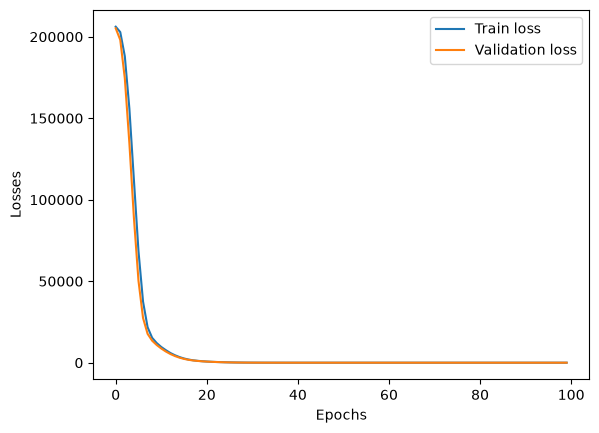

In [40]:
# visualizing the losses during training and testing 
sns.lineplot(
    x=range(0, epochs),
    y=train_losses,
    label="Train loss"
)

sns.lineplot(
    x=range(0, epochs),
    y=val_losses,
    label="Validation loss"
)

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()


In [41]:
# loading the saved model
ann_model.load_state_dict(torch.load("powerplant_ann_model.pt"))

C:\Users\User\AppData\Local\Temp\ipykernel_8744\1843894115.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ann_model.load_state_dict(torch.load("powerplant_ann_model.pt"

<All keys matched successfully>

In [42]:
# Evaluation

with torch.no_grad():
    ann_model.eval()
    y_train_pred = ann_model(X_train_tensor)
    y_test_pred = ann_model(X_test_tensor)
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

print("Training: ")
print("MSE: " + str(mse_train))
print("R2: " + str(r2_train))
print("Testing: ")
print("MSE: " + str(mse_test))
print("R2: " + str(r2_test))

Training: 
MSE: 21.307462692260742
R2: 0.9271594285964966
Testing: 
MSE: 19.552213668823242
R2: 0.931670069694519


# Machine Learning

In [43]:
# linear regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 4)","[[-14.77, -2.98, 0.34, -2.3 ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[454.4]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[136.81, 83.32, 64.59, 28. ]"


In [44]:
# decision tree
dt_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
dt_model.fit(
    X_train_scaled,
    y_train,    
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes ma

In [45]:
# xgboost
xgbr_model = XGBRegressor(
    max_depth=5
)
xgbr_model.fit(X_train_scaled, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [46]:
# Evaluation of Machine learning models
models = {
    "Linear Regression": lr_model,
    "Decision tree": dt_model,
    "XGBoost": xgbr_model
}

for name, model in models.items():
    print(name + ":")
    y_pred = model.predict(X_test_scaled)
    print(f"MSE: {str(mean_squared_error(y_test, y_pred))}")
    print(f"R2: {r2_score(y_test, y_pred)}")
    

Linear Regression:
MSE: 19.60808532568382
R2: 0.9314747936670361
Decision tree:
MSE: 18.570933948238252
R2: 0.9350993705167137
XGBoost:
MSE: 9.487181663513184
R2: 0.9668447375297546
